In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [45]:
from google.colab import files

uploaded = files.upload()

Saving HousingData.csv to HousingData (3).csv


In [46]:

df = pd.read_csv("HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [47]:
df.shape

(506, 14)

In [48]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [49]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [50]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [51]:
df["CRIM"].fillna(df["CRIM"].mode()[0],inplace=True)
df["ZN"].fillna(df["ZN"].mode()[0],inplace=True)
df["INDUS"].fillna(df["INDUS"].mode()[0],inplace=True)
df["CHAS"].fillna(df["CHAS"].mode()[0],inplace=True)
df["AGE"].fillna(df["AGE"].mode()[0],inplace=True)
df["LSTAT"].fillna(df["LSTAT"].mode()[0],inplace=True)



/tmp/ipykernel_4061/2049850602.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CRIM"].fillna(df["CRIM"].mode()[0],inplace=True)
/tmp/ipykernel_4061/2049850602.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [52]:
df.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


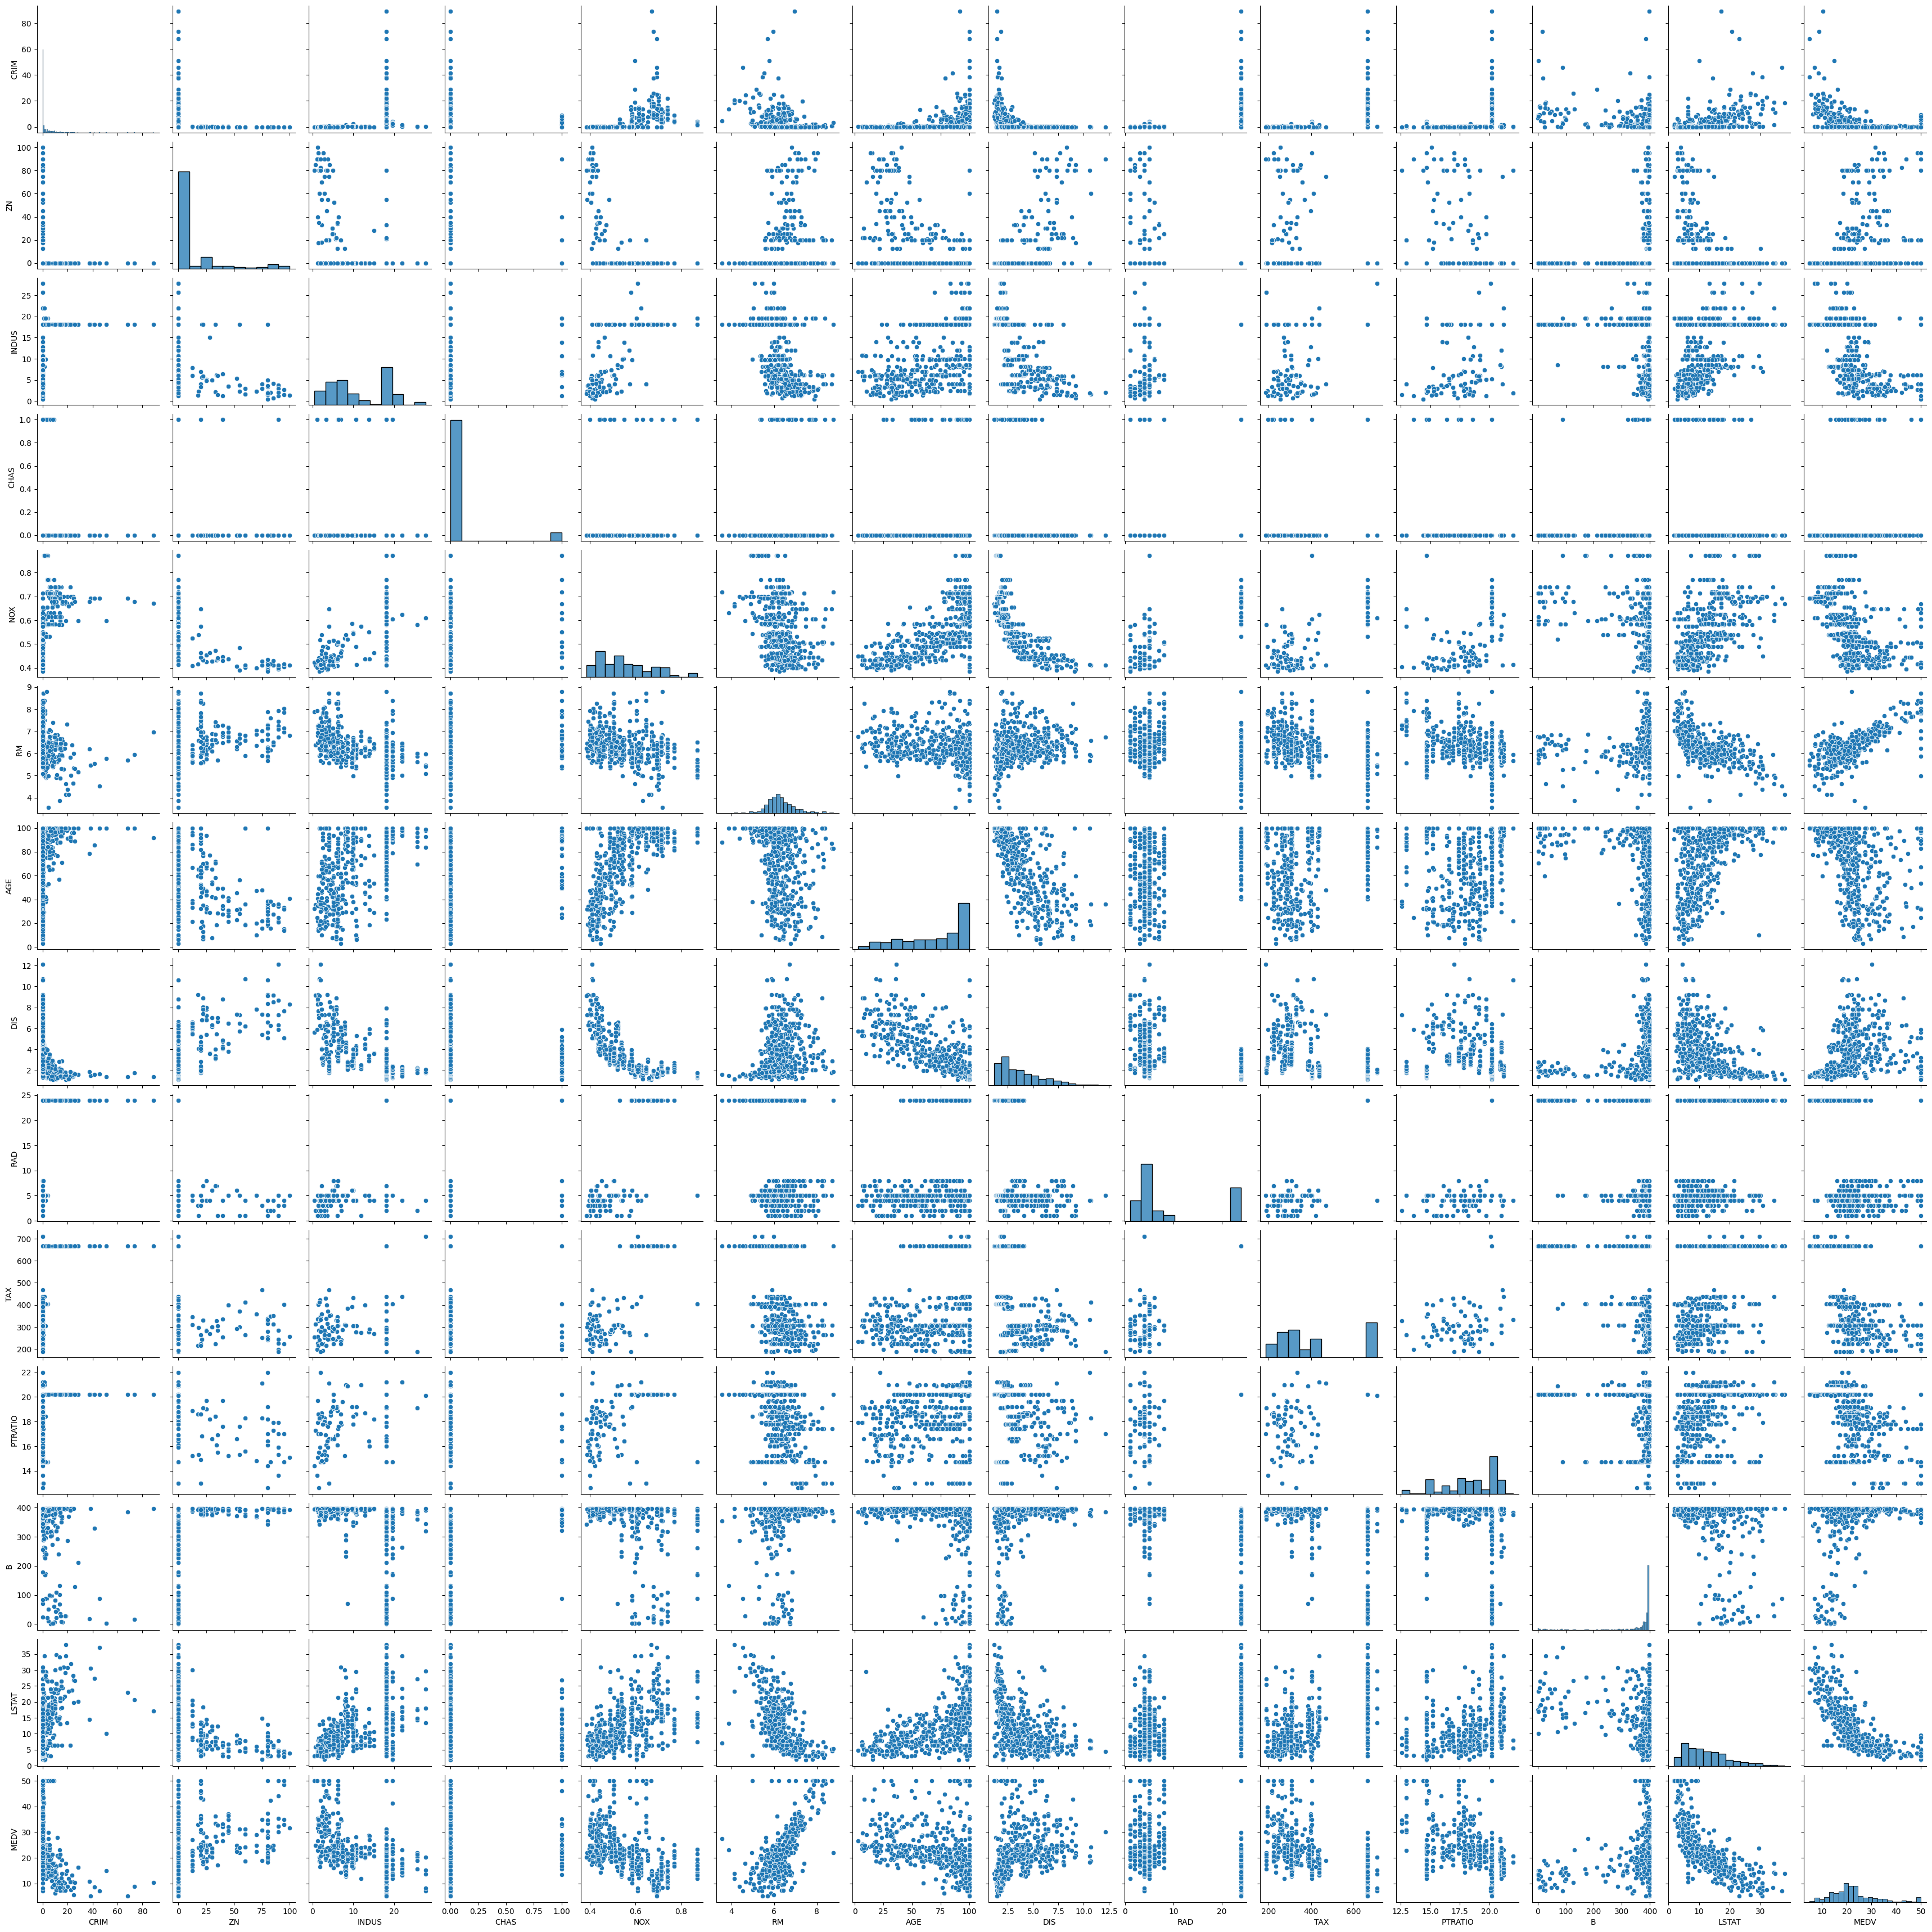

In [53]:
sns.pairplot(df)

In [54]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,6.36,36.2


In [90]:
X = df.drop("MEDV",axis=1)
print(X.shape)
Y = df["MEDV"]


(506, 13)


In [91]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=True,shuffle=True)

In [94]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((404, 13), (102, 13), (404,), (102,))

In [95]:
linear = LinearRegression()
linear.fit(x_train,y_train)
predicted = linear.predict(x_test)

In [96]:
r2_score(y_test,predicted)

0.751492225971874

In [87]:
predicted,y_test

(array([25.25974801, 22.71697378, 29.215158  , 11.44341222, 21.4872208 ,
        19.08325851, 19.74823863, 21.2425848 , 18.63356348, 20.12238883,
         4.46615086, 16.42329604, 16.77583582,  5.26443279, 39.67598414,
        32.77816644, 21.70555053, 37.14996759, 30.77893977, 23.00344796,
        24.62097245, 24.16519128, 20.69531395, 30.18181839, 22.35262351,
         9.01593761, 17.72298578, 18.06881935, 35.78171677, 21.21951171,
        17.86395737, 17.22123722, 20.06205242, 24.24447226, 28.44652107,
        19.04114893, 11.06371421, 23.88629488, 18.4773559 , 15.51097096,
        25.93609535, 21.07318899, 22.751556  , 15.02751605, 23.6350849 ,
        25.16440819, 20.00878322, 23.12588447, 10.37623328, 24.27909481,
        21.24023478, 17.66885657, 24.4542985 , 30.32595582, 13.24501277,
        22.07029477, 21.08943718, 16.02859443, 12.77788066, 22.70199808,
        18.16338511, 21.63183327, 31.38789645, 30.83270983, 17.04059547,
        32.76400539, 18.45936568, 20.47049241, 20.7

In [99]:
mean_absolute_error(y_test,predicted)

3.809026094376055

In [100]:
mean_squared_error(y_test,predicted)

24.559374569104477

In [101]:
np.sqrt(mean_squared_error(y_test,predicted))

np.float64(4.955741576101853)

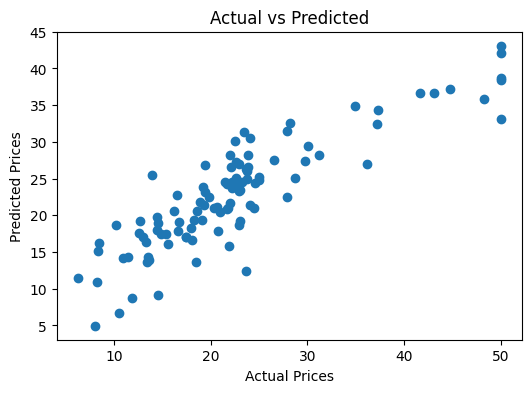

In [102]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, predicted)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [103]:
r2_score(y_test,predicted)

0.751492225971874